# 3D toric code — horizontal line at $h_z=0$: $O_{FM}^{m}$ + Rényi-2 transition

Locates the $m$-flux-loop **condensation** (topological$\to$trivial) transition along the
$h_x$ axis at $h_z=0$ from two independent local probes, extrapolated to $L\to\infty$.
This is the $e\!\leftrightarrow\!m$ **mirror** of `vertical_line_hz.ipynb`. The 3D toric code
is **not self-dual**, so $h_x^c \neq h_z^c$ — do **not** reuse $h_z^c=0.197$; the reference is
TBD-from-literature (`H_C_REF`, drawn only when set).

* **$O_{FM}^{m}$** — Fredenhagen–Marcu **membrane** ratio (aspect-½ cube, magnetic sector,
  telescoped estimator), `results/phase_hz0.0_memA0.5/`. **Rises** $0\to1$ across the
  transition (order parameter of the $m$-condensed / trivial phase).
* **$S_2$** — Rényi-2 entropy of the central plaquette, `results/phase_hz0.0_s2plaq/`.
  Sector-blind; **drops** $3\ln2\to0$. Its $dS_2/dh_x$ inflection is an independent $h_c(L)$.

Same fit machinery as the vertical-line notebook (symmetric **tanh** + asymmetric **Richards**;
inflection = pseudo-critical $h_x(L)$; **PDG** scale-factor error inflation; $h_x(L)=h_x^\infty+b(1/L)^x$).
Two membrane-specific additions: **§2b** the B3 estimator-health check (the $\sigma^x$ ratio is
heavy-tailed at small $h_x$), and a note that the electric string $O_{FM}^{e}$ is the **null test**
here (≈0 throughout — extract with `SECTOR=electric` to overlay).

Sections: **1** config · **2** data · **2b** B3 health · **3** curves · **4** models ·
**5** per-$L$ fits · **6** honest errors · **7** finite-size extrapolation.

In [11]:
# ====================== 1 · CONFIG — the one cell to edit ======================
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

ROOT   = "/Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/results"
FM_DIR = f"{ROOT}/phase_hz0.0_memA0.5"     # O_FM^m, aspect-1/2 cube membrane (fm_L*.json)
S2_DIR = f"{ROOT}/phase_hz0.0_s2plaq"      # Renyi-2 central plaquette (s2_L*.json)
FIELD  = "hx"                              # swept field (this line: h_x at h_z=0)

# ---- RANGE KNOB: only points with H_WINDOW[0] <= h <= H_WINDOW[1] enter the fits ----
H_WINDOW = (0.80, 1.30)                     # full hx grid; tighten around the rise once seen
EXCLUDE  = {}                               # {(obs, L): [h, ...]} drop specific bad points
#           obs in {"O_FM", "S2"};  use the B3 cell (§2b) to spot heavy-tailed membrane points

# ---- fits ----
FORMS   = ("tanh", "richards")              # baseline first, asymmetric second
N_BOOT  = 500                              # bootstrap resamples for honest h_c(L) errors

# ---- finite-size scaling:  h_c(L) = h_c(inf) + b*(1/L)**x ----
FSS_LS    = None                            # subset of L, e.g. [5, 6, 7]; None = all
FSS_FIX_X = None                            # pin x; None = fit x free (ill-constrained, 3-4 pts)
X_BATTERY = (1.0, 1.50, 2.0)                # systematic spread; NOT a claimed universality class

# The h_x m-condensation transition is NOT the h_z one (3D toric code is not self-dual):
# do NOT reuse h_z^c=0.197. Put a literature value here when known; None = no reference drawn.
H_C_REF = None                              # TBD-from-literature (m-loop condensation)
rng = np.random.default_rng(0)
print(f"field = {FIELD}   window = {H_WINDOW}   forms = {FORMS}   N_BOOT = {N_BOOT}")
print(f"H_C_REF = {H_C_REF}  (TBD-from-literature; the hx transition != hz transition)")

field = hx   window = (0.8, 1.3)   forms = ('tanh', 'richards')   N_BOOT = 500
H_C_REF = None  (TBD-from-literature; the hx transition != hz transition)


## 2 · Data library

Every point from both extractions, loaded into a single nested dict `DATA[obs][L]` with
`h`, `y`, `ye` arrays (`raw` keeps the full JSON record, incl. the membrane B3 fields).
`DATA["O_FM"]` = membrane $O_{FM}^{m}$, `DATA["S2"]` = central-plaquette $S_2$.

In [12]:
# ====================== 2 · DATA LIBRARY ======================
def _load(directory, val_key, err_key):
    recs = {}
    for jp in sorted(glob.glob(os.path.join(directory, "*.json"))):
        d = json.load(open(jp))
        recs[int(d["L"])] = dict(
            h=np.array(d["field"], float),
            y=np.array(d[val_key], float),
            ye=np.array(d.get(err_key, np.zeros(len(d["field"]))), float),
            raw=d)
    if not recs:
        raise SystemExit(f"no *.json in {directory}")
    return recs

DATA = {"O_FM": _load(FM_DIR, "O",  "Oe"),
        "S2":   _load(S2_DIR, "S2", "S2e")}
LABEL = {"O_FM": r"$O_{FM}^{m}$  (membrane)", "S2": r"$S_2$  (central plaquette)"}

def window_mask(h, obs, L):
    keep = (h >= H_WINDOW[0]-1e-9) & (h <= H_WINDOW[1]+1e-9)
    for hx in EXCLUDE.get((obs, L), []):
        keep &= ~np.isclose(h, hx, atol=1e-6)
    return keep

def points(obs, L, windowed=False):
    """(h, y, ye) for one (obs, L); windowed=True applies H_WINDOW + EXCLUDE."""
    d = DATA[obs][L]
    if not windowed:
        return d["h"], d["y"], d["ye"]
    m = window_mask(d["h"], obs, L)
    return d["h"][m], d["y"][m], d["ye"][m]

for obs in DATA:
    Ls = sorted(DATA[obs])
    print(f"[{obs}]  L = {Ls}")
    for L in Ls:
        h, y, ye = points(obs, L)
        hw, *_ = points(obs, L, windowed=True)
        print(f"    L={L}: {len(h):2d} pts (kept {len(hw):2d} in window)  "
              f"{FIELD} in [{h.min():.3g}, {h.max():.3g}]")

[O_FM]  L = [5, 6]
    L=5: 15 pts (kept 15 in window)  hx in [0.8, 1.3]
    L=6: 15 pts (kept 15 in window)  hx in [0.8, 1.3]
[S2]  L = [4, 5, 6]
    L=4: 15 pts (kept 15 in window)  hx in [0.8, 1.3]
    L=5: 15 pts (kept 15 in window)  hx in [0.8, 1.3]
    L=6: 15 pts (kept 15 in window)  hx in [0.8, 1.3]


## 2b · Membrane estimator health (B3)

The membrane $O_{FM}^{m}$ is an **off-diagonal** $\sigma^x$ estimator: deep in the topological
phase (small $h_x$) its per-sample amplitude ratio $\psi(\sigma\!\oplus\!m)/\psi(\sigma)$ is
heavy-tailed, so a point's error bar can be untrustworthy even when the mean looks reasonable.
`fm.py` records, per $h_x$ point, the worst-case **excess kurtosis** and the **min effective-
sample-size fraction** across all telescoping faces/orientations (`b3_max_kurt`,
`b3_min_ess_frac`). Points that breach the thresholds should be treated with suspicion — bump
`EVAL_SAMPLES` in the extraction, or `EXCLUDE` them from the fits. (S₂ is diagonal; no B3 needed.)

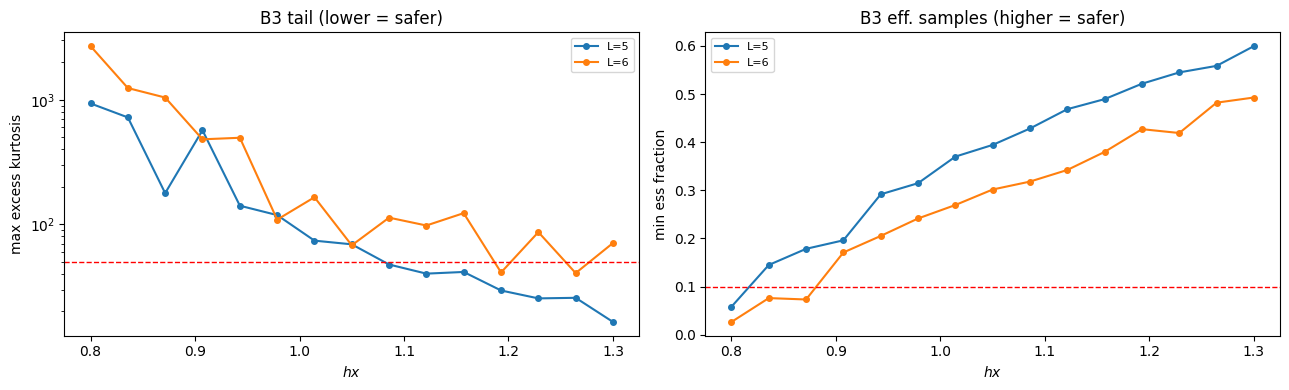

B3-flagged (heavy-tailed) membrane points — consider EXCLUDE or more samples:
  L=5: hx = [0.8, 0.8357, 0.8714, 0.9071, 0.9429, 0.9786, 1.0143, 1.05]
  L=6: hx = [0.8, 0.8357, 0.8714, 0.9071, 0.9429, 0.9786, 1.0143, 1.05, 1.0857, 1.1214, 1.1571, 1.2286, 1.3]


In [13]:
# ====================== 2b · MEMBRANE ESTIMATOR HEALTH (B3) ======================
KURT_MAX = 50.0      # excess kurtosis above this = heavy tail (Gaussian ~ 0)
ESS_MIN  = 0.10      # ess_frac below this = too few effective samples

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
flagged_b3 = {}
have_b3 = False
for L in sorted(DATA["O_FM"]):
    raw = DATA["O_FM"][L]["raw"]
    h = np.array(raw["field"], float)
    kurt, ess = raw.get("b3_max_kurt"), raw.get("b3_min_ess_frac")
    if kurt is None or ess is None:
        print(f"L={L}: no B3 fields in JSON (older extract?) — skipping"); continue
    have_b3 = True
    kurt, ess = np.array(kurt, float), np.array(ess, float)
    ax[0].semilogy(h, np.clip(kurt, 1e-3, None), "o-", ms=4, label=f"L={L}")
    ax[1].plot(h, ess, "o-", ms=4, label=f"L={L}")
    bad = (kurt > KURT_MAX) | (ess < ESS_MIN)
    if bad.any():
        flagged_b3[L] = [round(float(x), 4) for x in h[bad]]
ax[0].axhline(KURT_MAX, ls="--", c="r", lw=1)
ax[0].set(xlabel=f"${FIELD}$", ylabel="max excess kurtosis", title="B3 tail (lower = safer)")
ax[1].axhline(ESS_MIN, ls="--", c="r", lw=1)
ax[1].set(xlabel=f"${FIELD}$", ylabel="min ess fraction", title="B3 eff. samples (higher = safer)")
for a in ax: a.legend(fontsize=8)
plt.tight_layout(); plt.show()
if not have_b3:
    print("No B3 fields found — re-extract with the current fm.py to populate them.")
elif flagged_b3:
    print("B3-flagged (heavy-tailed) membrane points — consider EXCLUDE or more samples:")
    for L, hs in flagged_b3.items(): print(f"  L={L}: {FIELD} = {hs}")
else:
    print("No B3-flagged points: membrane error bars trustworthy across the grid.")

## 3 · Order parameters and their derivatives

Top row: raw $O_{FM}^{m}(h)$ (rising) and $S_2(h)$ (dropping) for every $L$ (shaded band = fit
window). Bottom row: finite-difference derivatives — the peak/dip is a model-free estimate of
the pseudo-critical field.

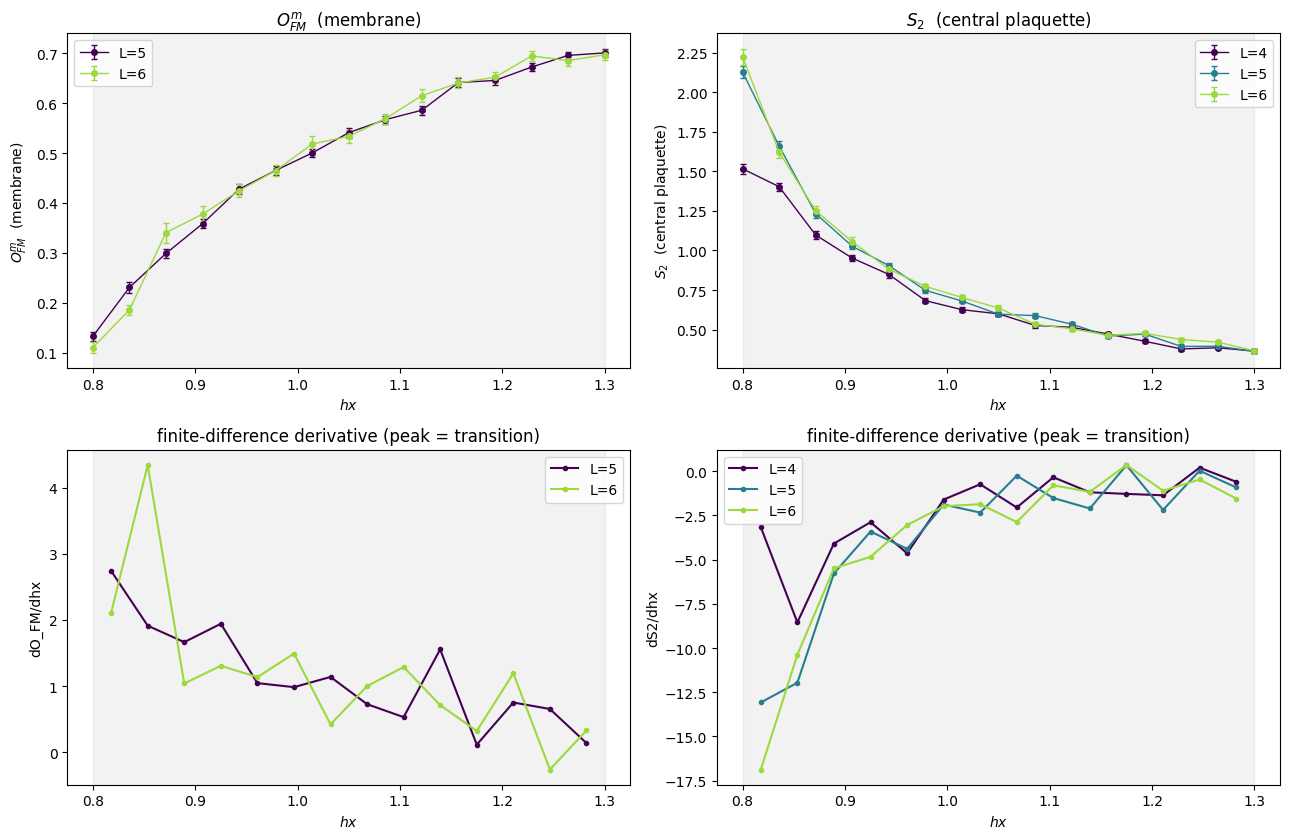

In [14]:
# ====================== 3 · CURVES + DERIVATIVES ======================
fig, ax = plt.subplots(2, 2, figsize=(13, 8.5))
obs_list = ("O_FM", "S2")
for j, obs in enumerate(obs_list):
    Ls = sorted(DATA[obs])
    colors = plt.cm.viridis(np.linspace(0, 0.85, len(Ls)))
    for L, c in zip(Ls, colors):
        h, y, ye = points(obs, L)
        ax[0, j].errorbar(h, y, yerr=ye, fmt="o-", ms=4, lw=1, capsize=2,
                          color=c, label=f"L={L}")
        hm = 0.5*(h[1:] + h[:-1]); d = np.diff(y)/np.diff(h)
        ax[1, j].plot(hm, d, "o-", ms=3, color=c, label=f"L={L}")
    for row in (0, 1):
        ax[row, j].axvspan(*H_WINDOW, color="k", alpha=0.05)
        if H_C_REF is not None:
            ax[row, j].axvline(H_C_REF, ls="--", color="green", lw=1.2, alpha=0.7)
    ax[0, j].set(xlabel=f"${FIELD}$", ylabel=LABEL[obs], title=LABEL[obs]); ax[0, j].legend()
    ax[1, j].set(xlabel=f"${FIELD}$", ylabel=f"d{obs}/d{FIELD}",
                 title="finite-difference derivative (peak = transition)"); ax[1, j].legend()
plt.tight_layout(); plt.show()

## 4 · Fit models

**Symmetric tanh** (4 params) — $O(h)=A+B\tanh\!\big((h-h_c)/w\big)$; $h_c$ is the inflection
directly ($B>0$ rising, $B<0$ falling). Robust, few parameters, forces point-symmetry about $h_c$.

**Richards / generalized logistic** (5 params) —
$O(h)=A+(K-A)\big[1+e^{-(h-h_0)/w}\big]^{-\nu}$, $\nu>0$ tunes asymmetry ($\nu=1\Rightarrow$
logistic). With $\nu\neq1$ the inflection is **not** $h_0$: $h_c = h_0 + w\ln\nu$, evaluated
exactly (and re-evaluated on every bootstrap resample). Both forms fit rising $O_{FM}^{m}$ and
falling $S_2$ unchanged (the $A,B$ / $A,K$ plateaus carry the direction).

In [ ]:
# ====================== 4 · FIT MODELS ======================
def richards(h, A, K, h0, w, nu):
    z = np.clip(-(h - h0)/w, -700, 700)        # guard exp overflow on the plateaus
    return A + (K - A) / (1.0 + np.exp(z))**nu

def tanh_model(h, A, B, hc, w):
    return A + B*np.tanh((h - hc)/w)

MODELS = {"richards": richards, "tanh": tanh_model}
NPAR   = {"richards": 5,        "tanh": 4}

def inflection(form, p):
    """Pseudo-critical field = inflection of the fitted curve."""
    if form == "richards":
        A, K, h0, w, nu = p
        return h0 + w*np.log(nu)               # exact inflection of the Richards curve
    A, B, hc, w = p
    return hc

def _p0_bounds(form, h, y):
    lo, hi = float(h.min()), float(h.max())
    hmid, span = 0.5*(lo+hi), (hi-lo) or 1.0
    yl, yr = float(y[0]), float(y[-1])
    if form == "richards":
        # A, K are the left/right plateaus (they carry the rise/fall direction); w>0, nu>0
        p0 = [yl, yr, hmid, 0.05*span, 1.0]
        bnds = ([-np.inf, -np.inf, lo-span, 1e-4, 1e-3],
                [ np.inf,  np.inf, hi+span, span,  50.0])
    else:
        p0 = [0.5*(yl+yr), 0.5*(yr-yl), hmid, 0.05*span]
        bnds = ([-np.inf, -np.inf, lo-span, 1e-4],
                [ np.inf,  np.inf, hi+span, span])
    return p0, bnds

def fit_curve(h, y, ye, form, escale=1.0):
    """Fit one windowed curve; return popt, chi2/dof and the inflection h_c."""
    f = MODELS[form]
    e = ye*escale
    use_w = np.all(np.isfinite(e)) and np.all(e > 0)
    kw = dict(sigma=e, absolute_sigma=True) if use_w else {}
    p0, bnds = _p0_bounds(form, h, y)
    popt, pcov = curve_fit(f, h, y, p0=p0, bounds=bnds, maxfev=80000, **kw)
    resid = y - f(h, *popt)
    chi2 = np.sum((resid/e)**2) if use_w else np.sum(resid**2)
    dof = max(1, len(h) - NPAR[form])
    return dict(popt=popt, pcov=pcov, chi2dof=chi2/dof,
                h_c=float(inflection(form, popt)), weighted=use_w)

## 5 · Per-$L$ fits

Both forms fit to the windowed data for every $L$. The dashed vertical is the inflection
$h_c(L)$; the printed $\chi^2/\nu$ is the input to the scale-factor inflation in §6 — values
$\gg1$ signal seed-to-seed training scatter (and, for the membrane, possibly heavy-tailed
points flagged in §2b).

In [ ]:
# ====================== 5 · PER-L FITS ======================
FITS = {}   # FITS[obs][form][L] = fit dict
for obs in ("O_FM", "S2"):
    FITS[obs] = {}
    for form in FORMS:
        FITS[obs][form] = {}
        for L in sorted(DATA[obs]):
            h, y, ye = points(obs, L, windowed=True)
            FITS[obs][form][L] = fit_curve(h, y, ye, form)

fig, ax = plt.subplots(len(FORMS), 2, figsize=(13, 4.4*len(FORMS)), squeeze=False)
for i, form in enumerate(FORMS):
    for j, obs in enumerate(("O_FM", "S2")):
        Ls = sorted(DATA[obs]); colors = plt.cm.viridis(np.linspace(0, 0.85, len(Ls)))
        print(f"\n[{obs} / {form}]  {'L':>2} {'h_c':>8} {'chi2/dof':>9} {'width':>8}"
              + ("  nu" if form == "richards" else ""))
        for L, c in zip(Ls, colors):
            fit = FITS[obs][form][L]; h, y, ye = points(obs, L, windowed=True)
            hh = np.linspace(h.min(), h.max(), 400)
            ax[i, j].errorbar(h, y, yerr=ye, fmt="o", ms=4, capsize=2, color=c, label=f"L={L}")
            ax[i, j].plot(hh, MODELS[form](hh, *fit["popt"]), "-", color=c)
            ax[i, j].axvline(fit["h_c"], ls="--", color=c, lw=0.8, alpha=0.6)
            extra = f"  {fit['popt'][4]:.2f}" if form == "richards" else ""
            w = abs(fit["popt"][3])
            print(f"    {L:>2} {fit['h_c']:>8.4f} {fit['chi2dof']:>9.1f} {w:>8.4f}{extra}")
        if H_C_REF is not None:
            ax[i, j].axvline(H_C_REF, ls="--", color="green", lw=1.2, alpha=0.7, label="ref")
        ax[i, j].set(xlabel=f"${FIELD}$", ylabel=LABEL[obs],
                     title=f"{form} fit — {obs}"); ax[i, j].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6 · Honest errors — PDG scale-factor inflation

The quoted per-point $\sigma_i$ capture only Monte-Carlo sampling variance of a *fixed* trained
network. The dominant scatter is **seed-to-seed NQS training variance** (each $(h,L)$ is an
independently optimized state), exposed by $\chi^2/\nu\gg1$. Following the PDG prescription:

1. fit with the quoted errors → $\chi^2/\nu$;
2. inflate: $s=\max(1,\sqrt{\chi^2/\nu})$, $\;\sigma_i\to s\,\sigma_i$;
3. bootstrap $h_c(L)$ with the **inflated** errors, relocating the inflection each resample.

The naive (un-inflated) bootstrap error is reported alongside. Treat the inflated error as a
**floor** (training bias can be coherent). For the membrane, a heavy-tailed point (§2b) can also
inflate $\chi^2/\nu$ — decide per point whether to trust it or `EXCLUDE` it.

In [ ]:
# ====================== 6 · HONEST ERRORS (scale-factor + bootstrap) ======================
def bootstrap_hc(obs, form, L, escale, B):
    h, y, ye = points(obs, L, windowed=True)
    e = ye*escale
    p0, bnds = _p0_bounds(form, h, y)
    lo, hi = h.min()-0.05, h.max()+0.05
    out = []
    for _ in range(B):
        yb = y + rng.normal(0, e)
        try:
            pb, _ = curve_fit(MODELS[form], h, yb, p0=p0, bounds=bnds,
                              sigma=e, absolute_sigma=True, maxfev=20000)
            hc = inflection(form, pb)
            if lo < hc < hi:
                out.append(hc)
        except Exception:
            pass
    return np.array(out)

HC = {}   # HC[obs][form][L] = dict(h_c, s, chi2dof, err_naive, err_honest)
for obs in ("O_FM", "S2"):
    HC[obs] = {}
    for form in FORMS:
        HC[obs][form] = {}
        print(f"\n[{obs} / {form}]  {'L':>2} {'h_c':>8} {'chi2/dof':>9} {'s':>5} "
              f"{'err_naive':>10} {'err_honest':>11}")
        for L in sorted(DATA[obs]):
            fit = FITS[obs][form][L]
            s = max(1.0, np.sqrt(fit["chi2dof"]))
            en = bootstrap_hc(obs, form, L, 1.0, N_BOOT)
            eh = bootstrap_hc(obs, form, L, s,   N_BOOT)
            HC[obs][form][L] = dict(
                h_c=fit["h_c"], s=s, chi2dof=fit["chi2dof"],
                err_naive=float(en.std()) if len(en) else np.nan,
                err_honest=float(eh.std()) if len(eh) else np.nan)
            r = HC[obs][form][L]
            print(f"    {L:>2} {r['h_c']:>8.4f} {r['chi2dof']:>9.1f} {r['s']:>5.1f} "
                  f"{r['err_naive']:>10.4f} {r['err_honest']:>11.4f}")

## 7 · Finite-size extrapolation

$h_c(L) = h_c^{\infty} + b\,(1/L)^x$, weighted by the honest $\sigma[h_c(L)]$ from §6.
`FSS_FIX_X` pins $x$; `None` fits $x$ freely (ill-constrained with 3-4 points — reported for
completeness). The `X_BATTERY` sweep gives the **systematic** spread from the exponent choice.
No universality class is assumed for the $m$-condensation transition — set `FSS_FIX_X` if you
have one from the literature.

In [ ]:
# ====================== 7 · FINITE-SIZE EXTRAPOLATION ======================
def fss(hc_by_L, use_L=None, fix_x=None):
    use_L = sorted(hc_by_L) if use_L is None else sorted(int(x) for x in use_L)
    L = np.array(use_L, float)
    y = np.array([hc_by_L[k]["h_c"]        for k in use_L])
    e = np.array([hc_by_L[k]["err_honest"] for k in use_L])
    w_ok = np.all(np.isfinite(e)) and np.all(e > 0)
    kw = dict(sigma=e, absolute_sigma=True) if w_ok else {}
    if fix_x is None:
        f = lambda LL, h0, b, x: h0 + b*(1.0/LL)**x
        p, c = curve_fit(f, L, y, p0=[y.min(), 0.3, 1.5],
                         bounds=([-np.inf, -np.inf, 0.1], [np.inf, np.inf, 6.0]),
                         maxfev=80000, **kw)
        h0, b, x = map(float, p); xerr = float(np.sqrt(abs(c[2, 2])))
    else:
        f = lambda LL, h0, b: h0 + b*(1.0/LL)**fix_x
        p, c = curve_fit(f, L, y, p0=[y.min(), 0.3], maxfev=80000, **kw)
        h0, b, x, xerr = float(p[0]), float(p[1]), float(fix_x), 0.0
    return dict(h0=h0, h0_err=float(np.sqrt(abs(c[0, 0]))), b=b, x=x, xerr=xerr,
                L=L, y=y, e=e, weighted=w_ok)

RESULT = {}
NEED = 2 if FSS_FIX_X is not None else 3    # sizes required for the 1/L^x fit
fig, ax = plt.subplots(len(FORMS), 2, figsize=(13, 4.4*len(FORMS)), squeeze=False)
for i, form in enumerate(FORMS):
    for j, obs in enumerate(("O_FM", "S2")):
        a = ax[i, j]
        avail = (sorted(HC[obs][form]) if FSS_LS is None
                 else sorted(set(HC[obs][form]) & set(int(x) for x in FSS_LS)))
        if len(avail) < NEED:                # extraction still in progress for this obs
            for L in avail:
                a.plot(1.0/L, HC[obs][form][L]["h_c"], "o", ms=8, color="C3")
            a.set(xlabel="$1/L$", ylabel="$h_c(L)$",
                  title=f"{obs} / {form}  (need ≥{NEED} L, have {avail})")
            print(f"[{obs} / {form}]  FSS deferred — have L={avail}, need ≥{NEED} "
                  f"(pull more sizes, then re-run)")
            continue
        F = fss(HC[obs][form], use_L=FSS_LS, fix_x=FSS_FIX_X)
        RESULT[(obs, form)] = F
        batt = []
        for xx in X_BATTERY:
            try: batt.append(fss(HC[obs][form], use_L=FSS_LS, fix_x=xx)["h0"])
            except Exception: pass
        syst = 0.5*(max(batt)-min(batt)) if batt else np.nan
        xtag = f"x={F['x']:.2f}" if FSS_FIX_X is not None else f"x free={F['x']:.2f}±{F['xerr']:.2f}"
        off = f"   offset vs ref {F['h0']-H_C_REF:+.4f}" if H_C_REF is not None else ""
        print(f"[{obs} / {form}]  h_c(inf) = {F['h0']:.4f} ± {F['h0_err']:.4f} (stat) "
              f"± {syst:.4f} (syst, exponent)   {xtag}{off}")

        invL = 1.0/F["L"]; grid = np.linspace(0, invL.max()*1.15, 200)
        a = ax[i, j]
        a.errorbar(invL, F["y"], yerr=(F["e"] if F["weighted"] else None),
                   fmt="o", ms=8, color="C3", capsize=3, label="$h_c(L)$")
        a.plot(grid, F["h0"] + F["b"]*grid**F["x"], "-", color="C3")
        a.plot(0, F["h0"], "*", ms=16, color="k", label=fr"$h_c(\infty)={F['h0']:.4f}$")
        if H_C_REF is not None:
            a.axhline(H_C_REF, ls="--", color="green", lw=1.4, label=f"ref = {H_C_REF}")
        a.set(xlabel="$1/L$", ylabel=f"$h_c(L)$", title=f"{obs} / {form}"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("\n--- summary: h_c(inf) ---")
for (obs, form), F in RESULT.items():
    print(f"  {obs:>5} / {form:<9}: {F['h0']:.4f} ± {F['h0_err']:.4f}")

## Next steps

Four independent estimates of $h_x^c$ are in `RESULT[(obs, form)]` (membrane $O_{FM}^{m}$ and
$S_2$ × tanh/Richards), each with a statistical (inflated-bootstrap) and a systematic
(exponent-choice) error. Before combining:

* **Grid coverage** — check the raw curves (§3): if $O_{FM}^{m}$ is still ≈0 at $h_x=0.8$ or has
  not saturated by $1.3$, extend the sweep before trusting any crossing.
* **B3** (§2b) — confirm no *near-transition* point is heavy-tailed; if it is, bump `EVAL_SAMPLES`.
* **Null test** — extract the electric string $O_{FM}^{e}$ on this same tree (`SECTOR=electric`)
  and confirm it stays ≈0 across the transition (e is confined in the m-condensed phase).
* Then combine (error-weighted mean, or $O_{FM}^{m}$/$S_2$ spread as a further systematic).